# Pretrained ResNet-50 Augmentation 10종 비교 실험

이 노트북은 Stanford Dogs 데이터셋에서 pretrained ResNet-50을 사용해
augmentation 강도와 MixUp/CutMix 조합을 비교합니다.

모든 실험은 동일한 데이터 분할, 초기 모델 가중치, optimizer, epoch 및 seed를 사용합니다.
따라서 주요 독립변수는 augmentation 구성입니다.

> 전체 실험을 실행할 때는 **커널을 재시작한 뒤 위에서부터 순서대로 실행**하세요.


## 1. 환경 및 seed 설정

- Epoch: 20
- Seed: 42
- Optimizer: SGD (`lr=0.001`)
- MixUp/CutMix alpha: 1.0
- 입력 크기: `3 x 224 x 224`


In [26]:
from pathlib import Path
import copy
import gc
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder


SEED = 42
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 0.001
MIX_ALPHA = 1.0
# 데이터 로딩과 augmentation을 병렬 처리
NUM_WORKERS = 2
COOLDOWN_EVERY_EPOCHS = 5
COOLDOWN_SECONDS = 60

DATASET_DIR = Path("~/datasets/stanfordimagenetdogs/Images").expanduser()
RESULT_DIR = Path("results_resnet50_aug")
HISTORY_DIR = RESULT_DIR / "histories"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print(f"Device: {DEVICE}")
print(f"Dataset: {DATASET_DIR}")
print(f"Results: {RESULT_DIR.resolve()}")


Device: cuda
Dataset: /home/thkim0/datasets/stanfordimagenetdogs/Images
Results: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_aug


## 2. 데이터셋과 transform 정의

기존 실험과 직접 비교하기 위해 정규화는 `mean=0.5`, `std=0.5`를 유지합니다.
validation 데이터에는 resize, tensor 변환, normalize만 적용하며 augmentation은 적용하지 않습니다.


In [ ]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"데이터셋을 찾을 수 없습니다: {DATASET_DIR}\n"
        "DATASET_DIR을 실제 Stanford Dogs Images 폴더로 수정하세요."
    )


def base_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5],
        ),
    ])


def augment_basic():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1),
    ])


def augment_mild(): # 색상 변화(jitter)가 좀 더 추가된 버전 
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
        ),
    ])


def augment_mildsafe(): # 좌우 회전이 더 추가된 버전 
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
        ),
    ])


AUGMENTATIONS = {
    "none": None,
    "basic": augment_basic,
    "mild": augment_mild,
    "mildsafe": augment_mildsafe,
}


full_dataset = ImageFolder(root=DATASET_DIR, transform=base_transform())
total_size = len(full_dataset)
train_size = int(0.583 * total_size)
val_size = total_size - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=split_generator,
)

class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Classes: {num_classes}")
print(f"Train: {len(train_subset):,} | Validation: {len(val_subset):,}")


Classes: 120
Train: 11,998 | Validation: 8,582


In [28]:
def compose_train_transform(augmentation_name):
    augmentation_factory = AUGMENTATIONS[augmentation_name]
    if augmentation_factory is None:
        return base_transform()

    return transforms.Compose([
        *augmentation_factory().transforms,
        *base_transform().transforms,
    ])


def make_loader(subset, augmentation_name="none", is_validation=False, seed=SEED):
    dataset_copy = copy.copy(subset.dataset)
    dataset_copy.transform = (
        base_transform()
        if is_validation
        else compose_train_transform(augmentation_name)
    )
    isolated_subset = Subset(dataset_copy, subset.indices)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        isolated_subset,
        batch_size=BATCH_SIZE,
        shuffle=not is_validation,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


val_loader = make_loader(
    val_subset,
    augmentation_name="none",
    is_validation=True,
)

sample_loader = make_loader(train_subset, augmentation_name="basic")
sample_images, sample_labels = next(iter(sample_loader))
print(f"Batch shape: {sample_images.shape}")
assert sample_images.shape[1:] == (3, 224, 224)


Batch shape: torch.Size([16, 3, 224, 224])


## 3. Augmentation 시각화 및 강도 점검

세 augmentation은 다음 순서로 변환 종류가 누적됩니다.

- **Basic**: 좌우 반전 + 밝기 변화
- **Mild**: Basic 계열 + 대비와 채도 변화
- **MildSafe**: Mild + 작은 회전(`±5°`)

`MildSafe`의 safe는 가장 약하다는 뜻이 아니라, 견종 label을 훼손할 가능성이 낮은 범위에서
변환 종류를 추가했다는 의미입니다.


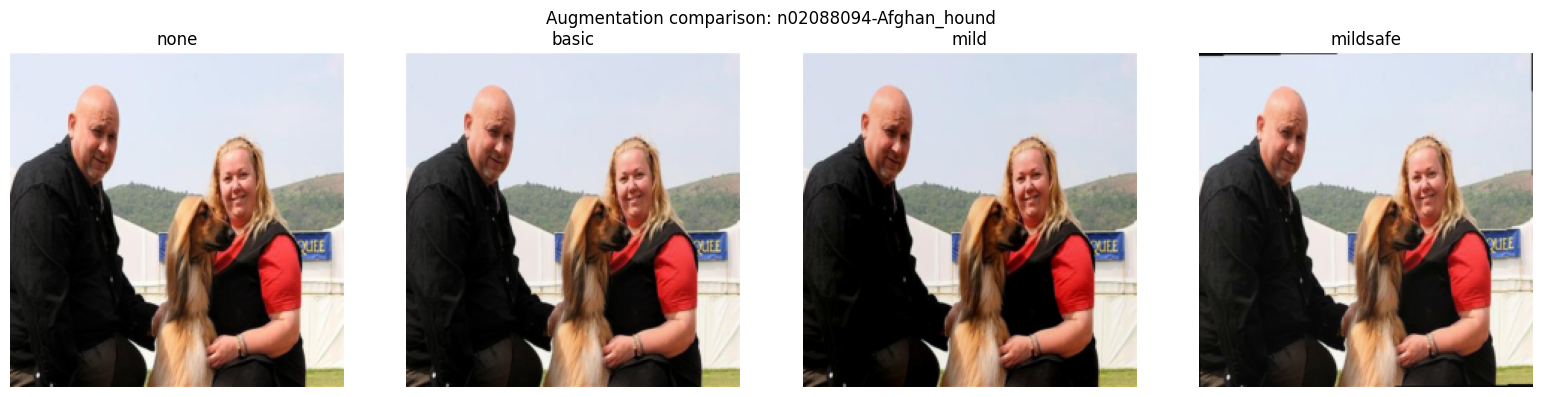

In [29]:
def denormalize(image):
    return torch.clamp(image * 0.5 + 0.5, 0, 1)


def show_augmentation_examples(subset, sample_index=0):
    original_image, label = subset.dataset.samples[subset.indices[sample_index]]
    from PIL import Image

    pil_image = Image.open(original_image).convert("RGB")
    names = ["none", "basic", "mild", "mildsafe"]

    fig, axes = plt.subplots(1, len(names), figsize=(16, 4))
    for ax, name in zip(axes, names):
        transformed = compose_train_transform(name)(pil_image)
        image = denormalize(transformed).permute(1, 2, 0).numpy()
        ax.imshow(image)
        ax.set_title(name)
        ax.axis("off")

    fig.suptitle(f"Augmentation comparison: {class_names[label]}")
    plt.tight_layout()
    plt.show()


show_augmentation_examples(train_subset)


## 4. 동일한 초기 모델과 MixUp/CutMix 정의

pretrained convolution 가중치와 새 FC layer까지 포함한 `initial_model_state`를 한 번만 만들고,
각 실험 모델에 동일하게 복사합니다. 이것이 augmentation 비교의 공정성을 유지하는 핵심입니다.


In [30]:
set_seed()
base_model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)
base_model.fc = nn.Linear(base_model.fc.in_features, num_classes)
initial_model_state = copy.deepcopy(base_model.state_dict())
del base_model


def create_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(initial_model_state)
    return model


def mixup_batch(images, labels, alpha=MIX_ALPHA):
    lam = float(np.random.beta(alpha, alpha))
    indices = torch.randperm(images.size(0), device=images.device)
    mixed_images = lam * images + (1.0 - lam) * images[indices]
    return mixed_images, labels, labels[indices], lam


def cutmix_batch(images, labels, alpha=MIX_ALPHA):
    lam = float(np.random.beta(alpha, alpha))
    indices = torch.randperm(images.size(0), device=images.device)

    height, width = images.shape[-2:]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_width = int(width * cut_ratio)
    cut_height = int(height * cut_ratio)

    center_x = torch.randint(width, (1,), device=images.device).item()
    center_y = torch.randint(height, (1,), device=images.device).item()

    x1 = max(center_x - cut_width // 2, 0)
    x2 = min(center_x + cut_width // 2, width)
    y1 = max(center_y - cut_height // 2, 0)
    y2 = min(center_y + cut_height // 2, height)

    mixed_images = images.clone()
    mixed_images[:, :, y1:y2, x1:x2] = images[
        indices, :, y1:y2, x1:x2
    ]

    replaced_ratio = ((x2 - x1) * (y2 - y1)) / (width * height)
    adjusted_lam = float(1.0 - replaced_ratio)
    assert 0.0 <= adjusted_lam <= 1.0

    return mixed_images, labels, labels[indices], adjusted_lam


test_images = torch.randn(4, 3, 224, 224, device=DEVICE)
test_labels = torch.arange(4, device=DEVICE)
_, _, _, test_mixup_lam = mixup_batch(test_images, test_labels)
_, _, _, test_cutmix_lam = cutmix_batch(test_images, test_labels)
assert 0.0 <= test_mixup_lam <= 1.0
assert 0.0 <= test_cutmix_lam <= 1.0
del test_images, test_labels


## 5. 공통 학습·검증 함수

일반 augmentation과 MixUp/CutMix 실험이 같은 history 구조를 사용합니다.
MixUp/CutMix의 train accuracy는 두 label에 대한 정확도를 `lam` 비율로 가중한 값입니다.


In [31]:
def evaluate(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct += outputs.argmax(dim=1).eq(labels).sum().item()
            total += batch_size

    return running_loss / total, 100.0 * correct / total


def train_experiment(model, train_loader, val_loader, experiment, epochs=EPOCHS):
    set_seed(SEED)
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)
    history = {
        "experiment": experiment["name"],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        weighted_correct = 0.0
        total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            batch_mix = experiment["batch_mix"]

            if batch_mix == "mixup":
                model_images, labels_a, labels_b, lam = mixup_batch(
                    images, labels
                )
            elif batch_mix == "cutmix":
                model_images, labels_a, labels_b, lam = cutmix_batch(
                    images, labels
                )
            else:
                model_images = images
                labels_a = labels_b = labels
                lam = 1.0

            optimizer.zero_grad()
            outputs = model(model_images)
            loss = (
                lam * criterion(outputs, labels_a)
                + (1.0 - lam) * criterion(outputs, labels_b)
            )
            loss.backward()
            optimizer.step()

            predicted = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            weighted_correct += (
                lam * predicted.eq(labels_a).sum().item()
                + (1.0 - lam) * predicted.eq(labels_b).sum().item()
            )
            total += batch_size

        train_loss = running_loss / total
        train_accuracy = 100.0 * weighted_correct / total
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"[{experiment['name']}] Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.2f}% | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_accuracy:.2f}%"
        )

        if epoch % COOLDOWN_EVERY_EPOCHS == 0 and epoch < epochs:
            print(
                f"GPU 냉각을 위해 {COOLDOWN_SECONDS}초간 대기합니다. "
                f"({epoch}/{epochs} epoch 완료)"
            )
            time.sleep(COOLDOWN_SECONDS)

    return history


## 6. 10개 실험 설정과 결과 저장 함수

`training_history.csv`는 실험이 하나 끝날 때마다 다시 저장됩니다.
따라서 장시간 실행 중 중단되더라도 완료된 실험 결과는 남습니다.


In [32]:
EXPERIMENTS = [
    {"name": "no_aug", "augmentation": "none", "batch_mix": "none"},
    {"name": "basic", "augmentation": "basic", "batch_mix": "none"},
    {"name": "mild", "augmentation": "mild", "batch_mix": "none"},
    {"name": "mildsafe", "augmentation": "mildsafe", "batch_mix": "none"},
    {"name": "basic_mixup", "augmentation": "basic", "batch_mix": "mixup"},
    {"name": "basic_cutmix", "augmentation": "basic", "batch_mix": "cutmix"},
    {"name": "mild_mixup", "augmentation": "mild", "batch_mix": "mixup"},
    {"name": "mild_cutmix", "augmentation": "mild", "batch_mix": "cutmix"},
    {
        "name": "mildsafe_mixup",
        "augmentation": "mildsafe",
        "batch_mix": "mixup",
    },
    {
        "name": "mildsafe_cutmix",
        "augmentation": "mildsafe",
        "batch_mix": "cutmix",
    },
]


experiment_config = {
    "model": "resnet50",
    "weights": "IMAGENET1K_V1",
    "dataset": str(DATASET_DIR),
    "num_classes": num_classes,
    "train_size": len(train_subset),
    "validation_size": len(val_subset),
    "image_size": [224, 224],
    "normalization_mean": [0.5, 0.5, 0.5],
    "normalization_std": [0.5, 0.5, 0.5],
    "epochs": EPOCHS,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "optimizer": "SGD",
    "learning_rate": LEARNING_RATE,
    "mix_alpha": MIX_ALPHA,
    "experiments": EXPERIMENTS,
}

with (RESULT_DIR / "experiment_config.json").open("w", encoding="utf-8") as file:
    json.dump(experiment_config, file, ensure_ascii=False, indent=2)


def histories_to_dataframe(histories):
    rows = []
    for experiment_name, history in histories.items():
        for epoch_index in range(len(history["val_accuracy"])):
            rows.append({
                "experiment": experiment_name,
                "epoch": epoch_index + 1,
                "train_loss": history["train_loss"][epoch_index],
                "train_accuracy": history["train_accuracy"][epoch_index],
                "val_loss": history["val_loss"][epoch_index],
                "val_accuracy": history["val_accuracy"][epoch_index],
            })
    return pd.DataFrame(rows)


def build_summary(histories):
    experiment_lookup = {
        experiment["name"]: experiment for experiment in EXPERIMENTS
    }
    rows = []

    for experiment_name, history in histories.items():
        best_index = int(np.argmax(history["val_accuracy"]))
        config = experiment_lookup[experiment_name]
        rows.append({
            "experiment": experiment_name,
            "augmentation": config["augmentation"],
            "batch_mix": config["batch_mix"],
            "best_epoch": best_index + 1,
            "best_val_accuracy": history["val_accuracy"][best_index],
            "final_val_accuracy": history["val_accuracy"][-1],
            "final_val_loss": history["val_loss"][-1],
        })

    return pd.DataFrame(rows)


def save_accumulated_results(histories):
    history_df = histories_to_dataframe(histories)
    summary_df = build_summary(histories)
    history_df.to_csv(RESULT_DIR / "training_history.csv", index=False)
    summary_df.to_csv(RESULT_DIR / "experiment_summary.csv", index=False)
    return history_df, summary_df


## 7. 10개 실험 순차 실행

아래 셀은 GPU에서 오랜 시간이 걸립니다. 각 실험이 끝나면 history와 CSV가 즉시 저장됩니다.
이미 20 epoch가 정상 저장된 실험은 다시 실행하지 않고 불러오므로, 중단 후 재실행할 수 있습니다.


In [ ]:
all_histories = {}

for experiment in EXPERIMENTS:
    experiment_name = experiment["name"]
    history_path = HISTORY_DIR / f"{experiment_name}.pt"

    if history_path.exists():
        saved_history = torch.load(history_path, map_location="cpu")
        if len(saved_history.get("val_accuracy", [])) == EPOCHS:
            all_histories[experiment_name] = saved_history
            print(f"[SKIP] {experiment_name}: 저장된 20 epoch 결과를 불러왔습니다.")
            save_accumulated_results(all_histories)
            continue

        print(f"[RESTART] {experiment_name}: 불완전한 history를 다시 학습합니다.")

    print(f"\n{'=' * 70}")
    print(
        f"Start: {experiment_name} | "
        f"augmentation={experiment['augmentation']} | "
        f"batch_mix={experiment['batch_mix']}"
    )
    print(f"{'=' * 70}")

    train_loader = make_loader(
        train_subset,
        augmentation_name=experiment["augmentation"],
        is_validation=False,
        seed=SEED,
    )
    model = create_model()
    history = train_experiment(
        model,
        train_loader,
        val_loader,
        experiment,
        epochs=EPOCHS,
    )

    assert len(history["val_accuracy"]) == EPOCHS
    torch.save(history, history_path)
    all_histories[experiment_name] = history
    save_accumulated_results(all_histories)

    model.to("cpu")
    del model, train_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

training_history_df, experiment_summary_df = save_accumulated_results(
    all_histories
)
print("\n모든 실험이 완료되고 결과가 저장되었습니다.")


## 8. 저장된 결과 재로딩

학습을 다시 하지 않고 아래 셀부터 실행해 CSV 기반 표와 그래프를 복원할 수 있습니다.


In [33]:
training_history_df = pd.read_csv(RESULT_DIR / "training_history.csv")
experiment_summary_df = pd.read_csv(
    RESULT_DIR / "experiment_summary.csv"
)

expected_experiments = {experiment["name"] for experiment in EXPERIMENTS}
saved_experiments = set(training_history_df["experiment"].unique())
missing_experiments = expected_experiments - saved_experiments

if missing_experiments:
    print(f"아직 완료되지 않은 실험: {sorted(missing_experiments)}")
else:
    epoch_counts = training_history_df.groupby("experiment")["epoch"].count()
    assert (epoch_counts == EPOCHS).all()
    print("10개 실험의 20 epoch 결과가 모두 확인되었습니다.")

display(experiment_summary_df.round(4))


10개 실험의 20 epoch 결과가 모두 확인되었습니다.


,experiment,augmentation,batch_mix,best_epoch,best_val_accuracy,final_val_accuracy,final_val_loss
0,no_aug,none,none,17,84.1063,83.9897,0.5427
1,basic,basic,none,20,84.5258,84.5258,0.5247
2,mild,mild,none,18,84.6073,84.3859,0.5267
3,mildsafe,mildsafe,none,18,84.6306,84.5840,0.5212
4,basic_mixup,basic,mixup,17,83.4537,83.3955,0.6722
5,basic_cutmix,basic,cutmix,20,83.8383,83.8383,0.6769
6,mild_mixup,mild,mixup,17,83.5120,83.3722,0.6748
7,mild_cutmix,mild,cutmix,18,83.6984,83.5586,0.6791
8,mildsafe_mixup,mildsafe,mixup,20,83.4537,83.4537,0.6726
9,mildsafe_cutmix,mildsafe,cutmix,19,83.4537,83.3372,0.6793


## 9. 비교표와 그래프 저장


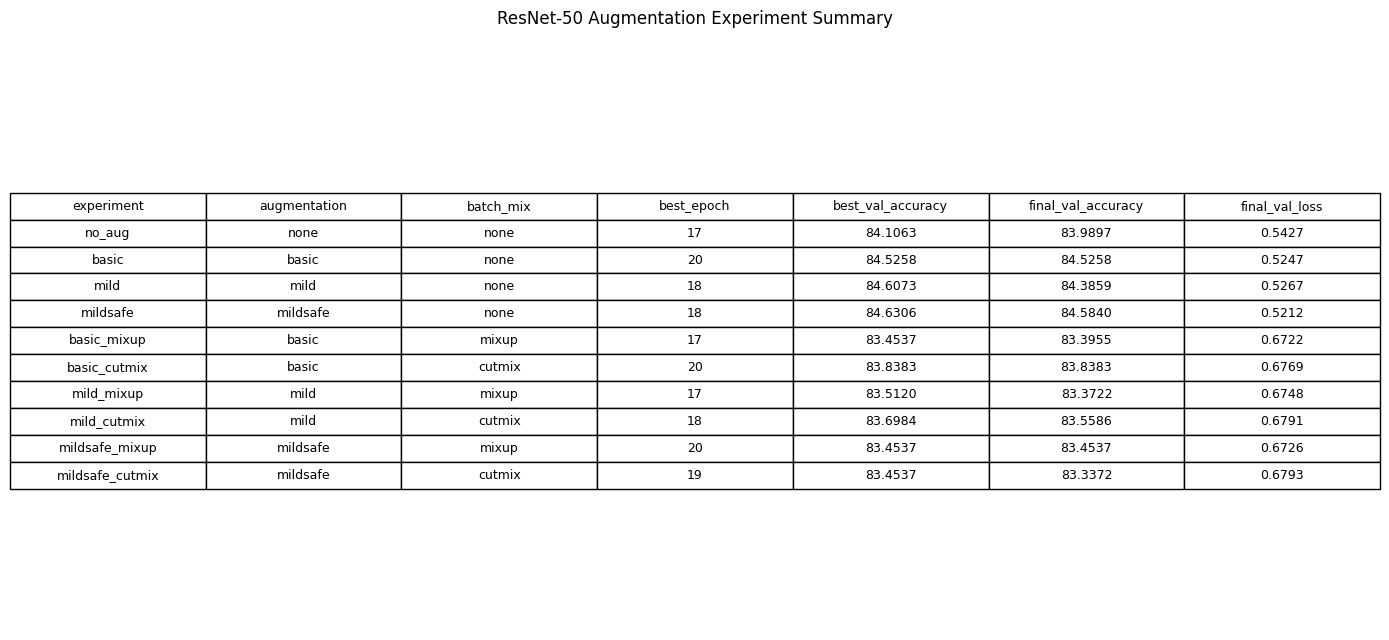

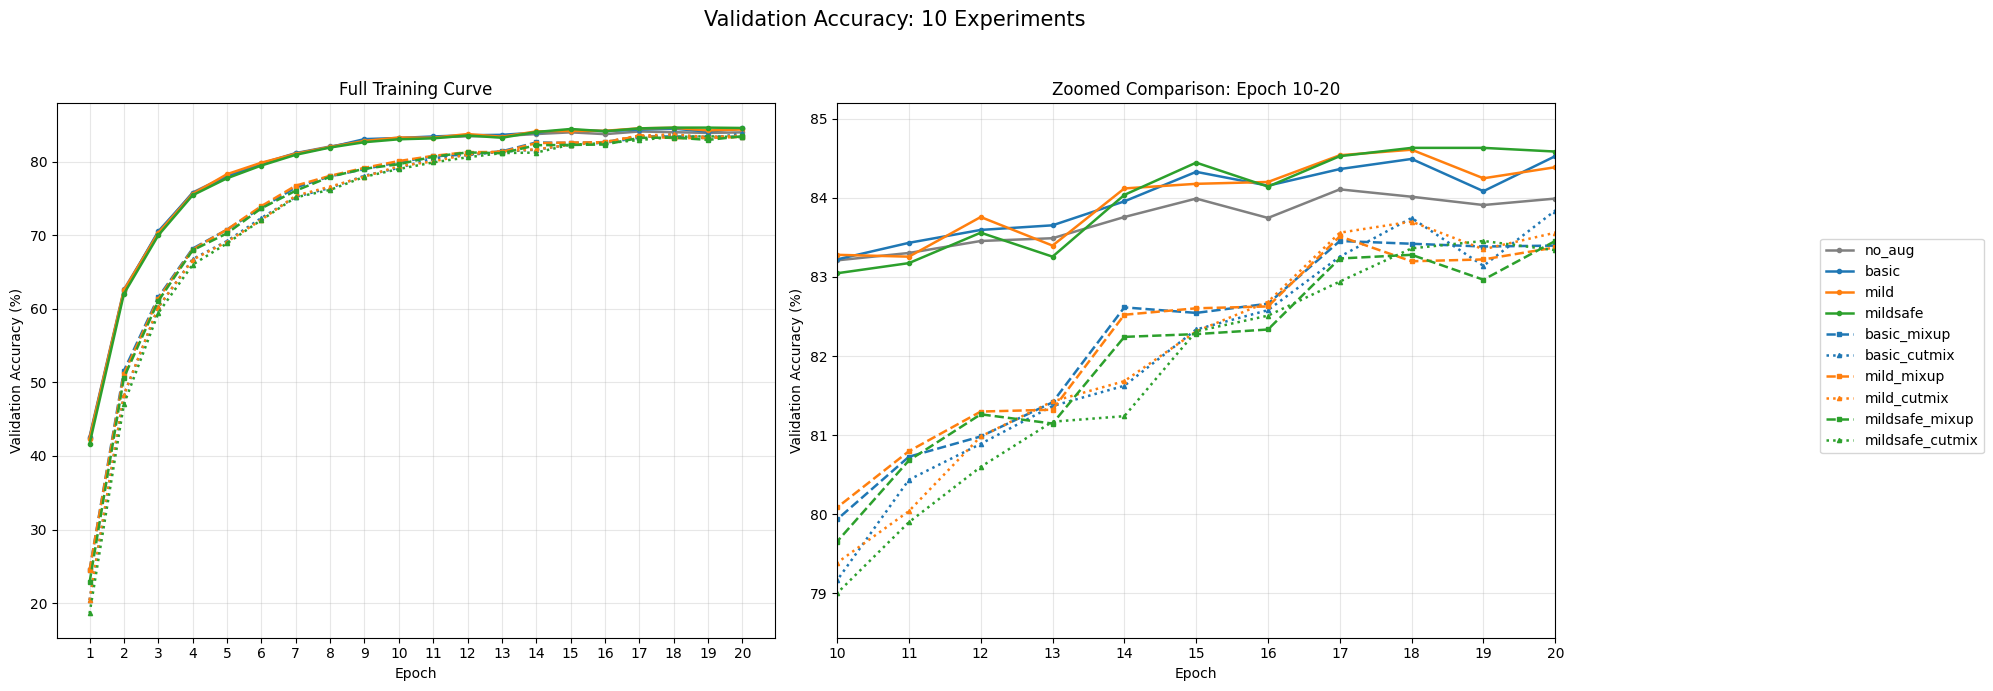

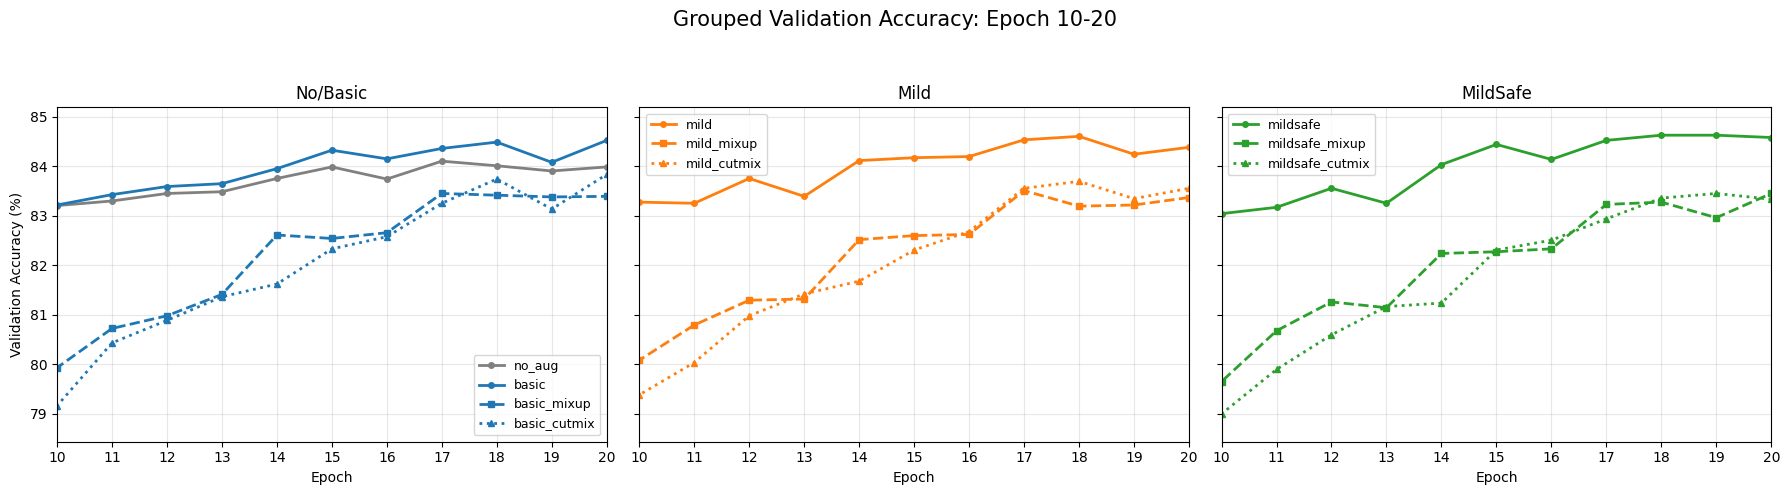

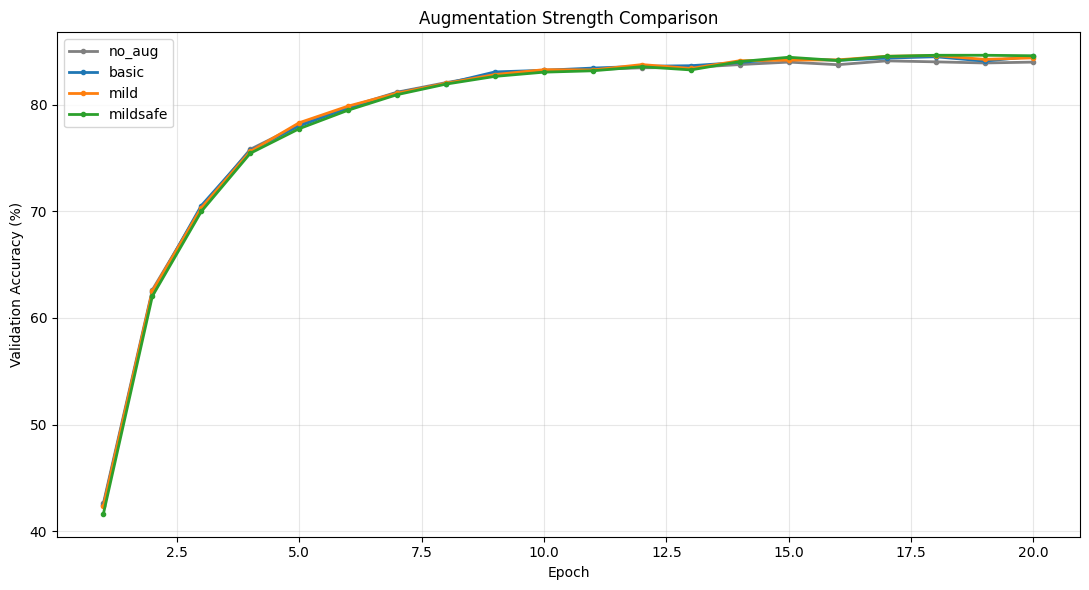

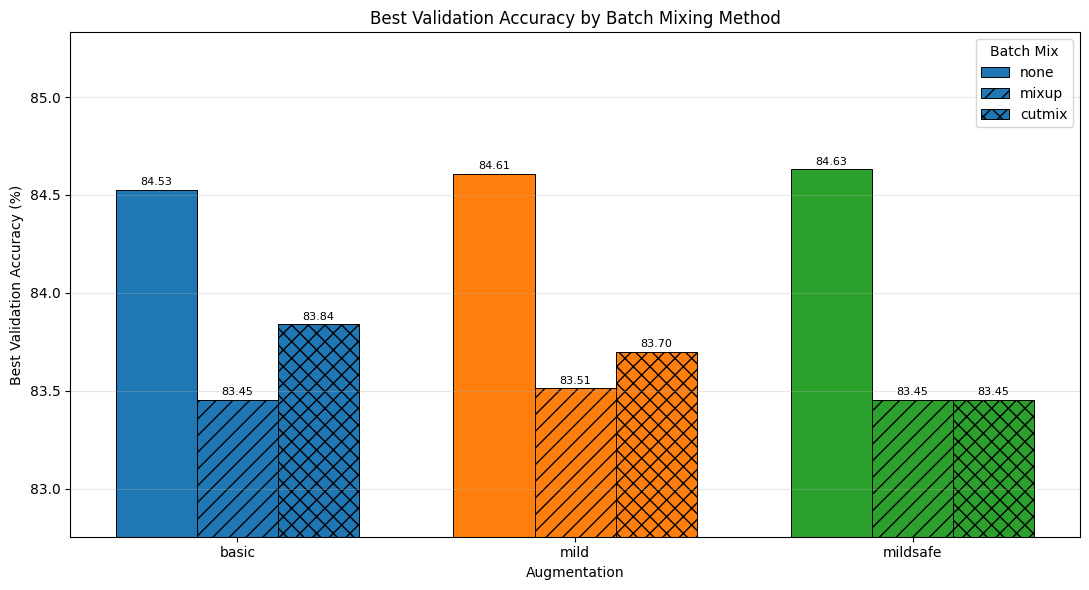

In [34]:
def save_summary_table(summary_df):
    display_df = summary_df.copy()
    for column in [
        "best_val_accuracy",
        "final_val_accuracy",
        "final_val_loss",
    ]:
        display_df[column] = display_df[column].map(lambda value: f"{value:.4f}")

    figure_height = max(4, 0.5 * len(display_df) + 1.5)
    fig, ax = plt.subplots(figsize=(14, figure_height))
    ax.axis("off")
    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)
    ax.set_title("ResNet-50 Augmentation Experiment Summary", pad=20)
    fig.tight_layout()
    fig.savefig(
        RESULT_DIR / "experiment_summary.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


AUGMENTATION_COLORS = {
    "none": "gray",
    "basic": "tab:blue",
    "mild": "tab:orange",
    "mildsafe": "tab:green",
}
BATCH_MIX_STYLES = {
    "none": {"linestyle": "-", "marker": "o"},
    "mixup": {"linestyle": "--", "marker": "s"},
    "cutmix": {"linestyle": ":", "marker": "^"},
}
EXPERIMENT_LOOKUP = {
    experiment["name"]: experiment for experiment in EXPERIMENTS
}


def experiment_plot_style(experiment_name):
    config = EXPERIMENT_LOOKUP[experiment_name]
    return {
        "color": AUGMENTATION_COLORS[config["augmentation"]],
        **BATCH_MIX_STYLES[config["batch_mix"]],
    }


def save_validation_accuracy_plot(history_df, zoom_start_epoch=10):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    experiment_names = list(history_df["experiment"].drop_duplicates())

    for experiment_name in experiment_names:
        group = history_df[history_df["experiment"] == experiment_name]
        style = experiment_plot_style(experiment_name)
        for ax in axes:
            ax.plot(
                group["epoch"],
                group["val_accuracy"],
                markersize=3,
                linewidth=1.8,
                label=experiment_name,
                **style,
            )

    axes[0].set_title("Full Training Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Validation Accuracy (%)")

    zoom_df = history_df[history_df["epoch"] >= zoom_start_epoch]
    zoom_min = zoom_df["val_accuracy"].min()
    zoom_max = zoom_df["val_accuracy"].max()
    zoom_padding = max(0.5, (zoom_max - zoom_min) * 0.1)
    axes[1].set_xlim(zoom_start_epoch, EPOCHS)
    axes[1].set_ylim(zoom_min - zoom_padding, zoom_max + zoom_padding)
    axes[1].set_title(f"Zoomed Comparison: Epoch {zoom_start_epoch}-{EPOCHS}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation Accuracy (%)")

    axes[0].set_xticks(range(1, EPOCHS + 1))
    axes[1].set_xticks(range(zoom_start_epoch, EPOCHS + 1))
    for ax in axes:
        ax.grid(True, alpha=0.3)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left")
    fig.suptitle("Validation Accuracy: 10 Experiments", fontsize=15)
    fig.tight_layout(rect=[0, 0, 0.88, 0.95])
    fig.savefig(
        RESULT_DIR / "validation_accuracy.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


def save_grouped_validation_accuracy(history_df, zoom_start_epoch=10):
    groups = {
        "No/Basic": ["no_aug", "basic", "basic_mixup", "basic_cutmix"],
        "Mild": ["mild", "mild_mixup", "mild_cutmix"],
        "MildSafe": ["mildsafe", "mildsafe_mixup", "mildsafe_cutmix"],
    }
    zoom_df = history_df[history_df["epoch"] >= zoom_start_epoch]
    zoom_min = zoom_df["val_accuracy"].min()
    zoom_max = zoom_df["val_accuracy"].max()
    zoom_padding = max(0.5, (zoom_max - zoom_min) * 0.1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
    for ax, (title, names) in zip(axes, groups.items()):
        for name in names:
            group = history_df[history_df["experiment"] == name]
            if group.empty:
                continue

            style = experiment_plot_style(name)
            ax.plot(
                group["epoch"],
                group["val_accuracy"],
                label=name,
                linewidth=2,
                markersize=4,
                **style,
            )

        ax.set_xlim(zoom_start_epoch, EPOCHS)
        ax.set_ylim(zoom_min - zoom_padding, zoom_max + zoom_padding)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_xticks(range(zoom_start_epoch, EPOCHS + 1))
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    axes[0].set_ylabel("Validation Accuracy (%)")
    fig.suptitle(
        f"Grouped Validation Accuracy: Epoch {zoom_start_epoch}-{EPOCHS}",
        fontsize=15,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(
        RESULT_DIR / "validation_accuracy_grouped.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


def save_augmentation_comparison(history_df):
    names = ["no_aug", "basic", "mild", "mildsafe"]
    fig, ax = plt.subplots(figsize=(11, 6))
    for name in names:
        group = history_df[history_df["experiment"] == name]
        if not group.empty:
            style = experiment_plot_style(name)
            ax.plot(
                group["epoch"],
                group["val_accuracy"],
                markersize=3,
                label=name,
                linewidth=2,
                **style,
            )

    ax.set_title("Augmentation Strength Comparison")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        RESULT_DIR / "augmentation_comparison.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


def save_batch_mix_comparison(summary_df):
    plot_df = summary_df[summary_df["augmentation"] != "none"].copy()
    pivot = plot_df.pivot(
        index="augmentation",
        columns="batch_mix",
        values="best_val_accuracy",
    )
    ordered_rows = [
        name for name in ["basic", "mild", "mildsafe"] if name in pivot.index
    ]
    ordered_columns = [
        name for name in ["none", "mixup", "cutmix"] if name in pivot.columns
    ]
    pivot = pivot.reindex(index=ordered_rows, columns=ordered_columns)

    fig, ax = plt.subplots(figsize=(11, 6))
    x_positions = np.arange(len(pivot.index))
    bar_width = 0.24
    hatch_map = {"none": "", "mixup": "//", "cutmix": "xx"}

    for column_index, batch_mix in enumerate(pivot.columns):
        offsets = x_positions + (column_index - 1) * bar_width
        bars = ax.bar(
            offsets,
            pivot[batch_mix],
            width=bar_width,
            color=[AUGMENTATION_COLORS[name] for name in pivot.index],
            hatch=hatch_map[batch_mix],
            edgecolor="black",
            linewidth=0.7,
            label=batch_mix,
        )
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)

    ax.set_title("Best Validation Accuracy by Batch Mixing Method")
    ax.set_xlabel("Augmentation")
    ax.set_ylabel("Best Validation Accuracy (%)")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(pivot.index)
    bar_min = pivot.min().min()
    bar_max = pivot.max().max()
    ax.set_ylim(bar_min - 0.7, bar_max + 0.7)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Batch Mix")
    fig.tight_layout()
    fig.savefig(
        RESULT_DIR / "batch_mix_comparison.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


save_summary_table(experiment_summary_df)
save_validation_accuracy_plot(training_history_df)
save_grouped_validation_accuracy(training_history_df)
save_augmentation_comparison(training_history_df)
save_batch_mix_comparison(experiment_summary_df)


## 10. 결과 해석 가이드

결과는 다음 흐름으로 해석합니다.

1. **No Augmentation vs Basic/Mild/MildSafe**
   - augmentation 종류가 추가될수록 일반화 성능이 개선되는지 확인합니다.
   - 변환이 지나치면 원본 데이터 분포와 멀어져 오히려 성능이 떨어질 수 있습니다.

2. **동일 augmentation에서 None vs MixUp vs CutMix**
   - MixUp은 두 이미지와 label을 선형 결합해 결정 경계를 부드럽게 만드는 regularization입니다.
   - CutMix는 한 이미지의 일부 영역을 다른 이미지로 교체해 국소 특징에 대한 의존을 줄입니다.

3. **과도한 regularization 가능성**
   - augmentation에 MixUp/CutMix까지 추가하면 학습 데이터가 더 어려워집니다.
   - train accuracy가 낮으면서 validation accuracy도 개선되지 않는다면 현재 20 epoch나
     optimizer 조건에서 regularization이 과했을 가능성이 있습니다.

4. **보고서 표현**
   - 이 실험은 seed 42에서 한 번 수행한 결과이므로,
     “항상 성능이 향상된다”가 아니라 “해당 조건에서 이러한 경향이 관찰되었다”고 작성합니다.

### 저장 파일

모든 결과는 `results_resnet50_aug/`에 저장됩니다. 모델 checkpoint는 저장하지 않습니다.
